### Loading Packages & Configs

In [145]:
import torch
from torch import nn
from torch.nn import functional as F
from loader import load_data, get_batch
from tokenizer import Tokenizer
from train import Trainer
from dataclasses import dataclass
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
@dataclass
class Config:
    batch_size: int = 4
    vocab_size: int = None
    seq_len: int = 8
    n_layer: int = 4
    max_iters: int = 5000
    eval_interval: int = 500
    learning_rate: float = 3e-4
    device: str = 'mps' if torch.mps.is_available() else 'cpu'
    eval_iters: int = 200
    n_embd: int = 32
    n_head: int = 4
    data_split: float = 0.9

### Loading Data

In [147]:
text = load_data(filename="data/sample-TinyStories.txt")

Number of stories: 73
Length of text: 57107 characters


### Building Tokenizer & Train, Val dataset

In [148]:
tokenizer = Tokenizer(text)

In [149]:
print(f"Vocabulary size: {tokenizer.vocab_size}")

Vocabulary size: 61


In [150]:
config = Config(vocab_size=tokenizer.vocab_size)

In [151]:
data = tokenizer.encode(text)
data = torch.tensor(data, dtype=torch.long)

In [152]:
train_data = data[:int(config.data_split*len(data))]
val_data = data[int(config.data_split*len(data)):]
print(f"Train data length: {len(train_data)}")

Train data length: 51396


### GPT Architecture

In [153]:
class AttentionHead(nn.Module):
    def __init__(self,d_head):
        super().__init__()
        self.Query = nn.Linear(config.n_embd,d_head,bias=False)
        self.Key = nn.Linear(config.n_embd,d_head,bias=False)
        self.Value = nn.Linear(config.n_embd,d_head,bias=False)
        self.register_buffer('tril',torch.tril(torch.ones(config.seq_len,config.seq_len)))

    def forward(self,x):
        _, seq_len, n_embed = x.shape 

        q = self.Query(x) # (batch, seq_len, d_head)
        k = self.Key(x) # (batch, seq_len, d_head)

        wei = q @ k.transpose(-2,-1)* n_embed**-0.5 # (batch, seq_len, seq_len)
        wei = wei.masked_fill(self.tril[:seq_len,:seq_len]==0,float('-inf'))
        wei = F.softmax(wei,dim=-1)

        v = self.Value(x) # (batch, seq_len, d_head)
        out = wei @ v ## (batch, seq_len, n_head)
        return out         


class MultiHeadAttention(nn.Module):
    def __init__(self,num_head,d_head):
        super().__init__()
        self.heads = nn.ModuleList([AttentionHead(d_head) for _ in range(num_head)])
        self.proj = nn.Linear(config.n_embd,config.n_embd)

    def forward(self,x):
        out = torch.cat([head(x) for head in self.heads],dim=-1)
        out = self.proj(out)
        return out

In [154]:
class FeedForward(nn.Module):
    def __init__(self,n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd,n_embd)
        )

    def forward(self,x):
        out = self.net(x)
        return out 

In [155]:
class TransformerBlock(nn.Module):
    def __init__(self,n_embed,n_head):
        super().__init__()
        d_head = n_embed // n_head
        self.sa_heads = MultiHeadAttention(n_head,d_head)
        self.ffwd = FeedForward(n_embed)
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)

    def forward(self,x):
        x = x + self.sa_heads(self.ln1(x))
        x = x  + self.ffwd(self.ln2(x))
        return x 

In [156]:
class BasicGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(config.vocab_size,config.n_embd)
        self.pos_embedding = nn.Embedding(config.seq_len,config.n_embd)
        self.multihead_attn = MultiHeadAttention(config.n_head, config.n_embd // config.n_head)
        #self.blocks = nn.Sequential(*[TransformerBlock(config.n_embd,config.n_head) for _ in range(config.n_layer)])
        self.linear = nn.Linear(config.n_embd,config.vocab_size)
        #self.layernorm = nn.LayerNorm(config.n_embd)

    def forward(self,x, target= None):
        batch, seq_len = x.shape
        token_embed = self.token_embedding(x) # (batch, seq_len, n_embed)
        pos_embed = self.pos_embedding(torch.arange(seq_len,device=config.device)) # (seq_len, n_embed)
        x = token_embed + pos_embed # (batch, seq_len, n_embed)
        x = self.multihead_attn(x) # (batch, seq_len, n_embed)
        #x = self.blocks(x) # (batch, seq_len, n_embed)
        #x = self.layernorm(x) # (batch, seq_len, n_embed)

        logits = self.linear(x)  # (batch, seq_len, n_vocab)

        if target is None:
            loss = None
        else:
            batch, seq_len, n_vocab = logits.shape 
            output = logits.view(batch*seq_len, n_vocab)
            target = target.view(batch*seq_len)
            loss = F.cross_entropy(output,target) 

        return logits, loss

    def generate(self,inputs, max_new_tokens):
        for _ in range(max_new_tokens):
            inputs_cond = inputs[:,-config.seq_len:] # (batch, seq_len)
            logits, _ = self(inputs_cond) # (batch, seq_len, vocab_size)
            logits = logits[:,-1,:] # (batch, vocab_size)
            probs = F.softmax(logits,dim=1) # (batch, vocab_size)
            next_token = torch.multinomial(probs,num_samples=1) 
            inputs = torch.cat((inputs, next_token),dim=1) #(batch, seq_len+1)
        return inputs[0]
        

In [157]:
model = BasicGPT()
model = model.to(config.device)

In [158]:
parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {parameters} | Number of trainable parameters: {parameters/1e6:.2f}M")

Parameters: 8349 | Number of trainable parameters: 0.01M


In [159]:
trainer = Trainer(model, train_data, val_data, config)

trainer.set_experiment("pos-embed + multi-attn")  
trainer.train()

trainer.save_history("experiment_history.json")

step    500 | train loss 2.9433 | val loss 2.9273 |    6.24 ms/step |      5135 tok/s 
step   1000 | train loss 2.7856 | val loss 2.7606 |    5.76 ms/step |      5551 tok/s 
step   1500 | train loss 2.5998 | val loss 2.6426 |    5.72 ms/step |      5596 tok/s 
step   2000 | train loss 2.5165 | val loss 2.5529 |    5.71 ms/step |      5600 tok/s 
step   2500 | train loss 2.5035 | val loss 2.5172 |    5.71 ms/step |      5602 tok/s 
step   3000 | train loss 2.4555 | val loss 2.4333 |    5.71 ms/step |      5604 tok/s 
step   3500 | train loss 2.4026 | val loss 2.3955 |    5.71 ms/step |      5608 tok/s 
step   4000 | train loss 2.4129 | val loss 2.3965 |    5.69 ms/step |      5619 tok/s 
step   4500 | train loss 2.3468 | val loss 2.3560 |    5.70 ms/step |      5613 tok/s 


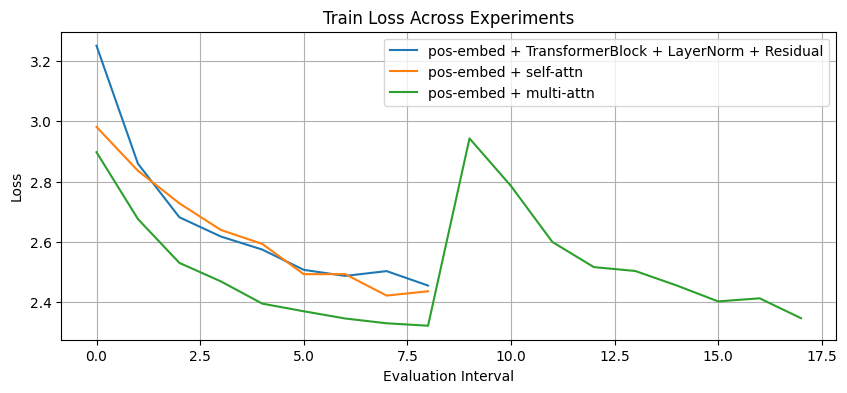

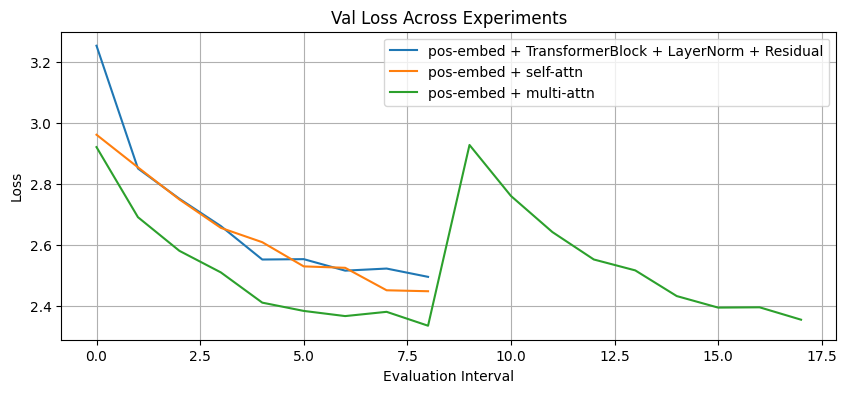

In [160]:
import matplotlib.pyplot as plt

def plot_history(split: str, save_path: str = None):
    """
    Plots train and validation loss curves for multiple experiments.

    Args:
        split (str): The split to plot ("train" or "val").
        save_path (str, optional): If provided, saves the plot to this file path.
    """
    plt.figure(figsize=(10, 4))

    import json 
    with open('experiment_history.json') as f:
        history = json.load(f)

    for exp_name, hist in history.items():
        losses = hist.get(split, [])    


        if losses:
            plt.plot(losses, label=f"{exp_name}")

    plt.xlabel("Evaluation Interval")
    plt.ylabel("Loss")
    plt.title(f"{split.capitalize()} Loss Across Experiments")
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Plot saved to {save_path}")

    plt.show()

plot_history('train')
plot_history('val')

In [162]:
from plot_metrics import plot_metrics_history
plot_metrics_history('metrics.json', metric='ms_per_step')

FileNotFoundError: metrics.json

In [ ]:
plot_metrics_history('metrics.json', metric='tok_per_sec')

In [130]:
context = torch.zeros((1,1),dtype=torch.long,device='mps')

In [131]:
tokens = model.generate(context,1000).tolist()

In [132]:
print(tokenizer.decode(tokens))



"ke woe led. yamand cam ce sang we fie waked bond Tnund d sound Thedpom lan ann thmantokd goroled, hii.nowasor. finrhe we. the lo athenthered and ly Ay ls ten. ther.
?k avs. w Hen thouby nthes sithe truibeyuh tha " bB, Lir, n. fitoot wamre ltheand.thed wey q ind itome , Ter ved asithernc a f. fan alou, rlispadit. wy be t.l ve an l an theolok.
"Hed tanseykele and hea, t wato! plily ! man, Tom. hecadotouny the s t wan f yore st d to.


Thed Sitome Fsamme wabe w he he shit Sadspo ppy, "! c m sian!h t S" atoanery, owasotoy ten s."T. we tt thenthlythet The Tholinon fad tker tha s shFe ihem as y tey me bar w, ly. wn wihend.am thngoud ay spt he avayad lehe othetoasu,d. Tdom hindy, litt te l s t a weds smW- tomy ashapastlthin cy tterunoysund amo hthiy"hheS d s t Third- towasud. timet Tllothe " wan o w addang g isatid wedr.
n t n ner.

veno. gy. The spy amer tihesthd m: thed te ogt. ad fu w ckwan ard Th tsed bil ore. Ted w sanaowe c
m w w s. lwthes az. aroom d ar
"
themM. wo lan an rdusroud k